# Lecture 6b — Forecasting Risk: EWMA, GARCH, HAR and Machine Learning

**25882 AI-powered Investment and Risk Management** · UTS Business School

---

Lectures 2, 3 and 5 kept arriving at the same conclusion from different directions:
**returns are close to unforecastable, and risk is not.** This notebook is where we cash
that in.

The plan:

1. **Establish the asymmetry.** Look at the autocorrelation of returns against the
   autocorrelation of absolute returns, and run the same regression on both.
2. **Climb the estimator ladder.** Rolling window → EWMA → GARCH(1,1) → HAR, and see what
   each rung actually buys.
3. **Add machine learning.** Random forest, gradient boosting and a small neural network on
   the same information set, evaluated out of sample.
4. **Discover that the loss function decides the winner.** Score the same models with
   QLIKE and with RMSE and watch the ranking change.

Point 4 is the one that matters most, and it is the point most often skipped.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from arch import arch_model
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import airm6 as a6

USE_LIVE = False
RANDOM_STATE = 42

prices = a6.get_prices()
returns = a6.log_returns(prices)
r = a6.portfolio_returns(returns)          # equally weighted S&P 500 panel

print(f"{len(r):,} daily observations, {r.index.min().date()} to {r.index.max().date()}")
print(f"Annualised volatility: {a6.annualise_vol(r.std()) * 100:.2f}%")

1,258 daily observations, 2013-02-11 to 2018-02-07
Annualised volatility: 12.71%


---
## 1. The asymmetry, in one picture

If returns were forecastable from their own past, the autocorrelation function would show
it. Let us plot the ACF of $r_t$ next to the ACF of $|r_t|$.

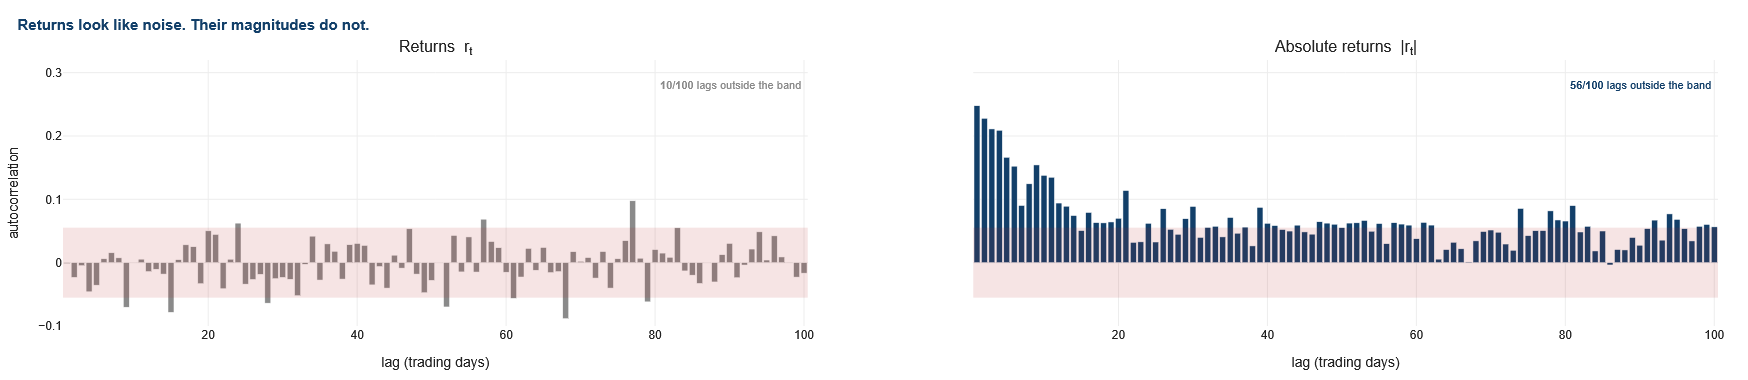

lag-1 autocorrelation of r_t    -0.001
lag-1 autocorrelation of |r_t|  +0.248
lag-100 autocorrelation of |r_t| +0.057   (still positive after 5 months)


In [2]:
def acf(x, max_lag):
    x = np.asarray(x, dtype=float) - np.mean(x)
    denom = x @ x
    return np.array([x[:-k] @ x[k:] / denom for k in range(1, max_lag + 1)])

LAGS = 100
band = 1.96 / np.sqrt(len(r))
acf_r, acf_abs = acf(r, LAGS), acf(r.abs(), LAGS)

fig = make_subplots(rows=1, cols=2, shared_yaxes=True,
                    subplot_titles=("Returns  r<sub>t</sub>",
                                    "Absolute returns  |r<sub>t</sub>|"))
for col, (vals, colour) in enumerate([(acf_r, a6.GREY), (acf_abs, a6.NAVY)], start=1):
    fig.add_trace(go.Bar(x=np.arange(1, LAGS + 1), y=vals, marker_color=colour,
                         showlegend=False), row=1, col=col)
    fig.add_hrect(y0=-band, y1=band, fillcolor=a6.RED, opacity=0.12,
                  line_width=0, row=1, col=col)
    outside = int(np.sum(np.abs(vals) > band))
    fig.add_annotation(x=LAGS, y=0.28, xref=f"x{col}", yref="y",
                       text=f"<b>{outside}/100</b> lags outside the band",
                       showarrow=False, xanchor="right", font=dict(size=11, color=colour))

a6.style(fig, title="Returns look like noise. Their magnitudes do not.", height=380,
         legend_top=False)
fig.update_yaxes(title="autocorrelation", range=[-0.10, 0.32], row=1, col=1)
fig.update_xaxes(title="lag (trading days)")
fig.show()

print(f"lag-1 autocorrelation of r_t    {acf_r[0]:+.3f}")
print(f"lag-1 autocorrelation of |r_t|  {acf_abs[0]:+.3f}")
print(f"lag-100 autocorrelation of |r_t| {acf_abs[99]:+.3f}   (still positive after 5 months)")

The left panel is what an efficient market looks like: the lags outside the shaded band are
roughly what you would expect from chance alone at a 5% test size.

The right panel is **volatility clustering** — calm follows calm, turmoil follows turmoil
([Cont, 2001](https://doi.org/10.1080/713665670)). The decay is slow: the autocorrelation
is still positive five months out. That persistence is the raw material every model in this
notebook exploits.

Let us put a number on it by running the *same* regression on both.

In [3]:
rv = a6.realised_var_proxy(r)          # squared daily return
X_var = a6.har_design(rv)              # daily / weekly / monthly lags, all shifted

def r_squared(X, y):
    Xd = np.c_[np.ones(len(X)), np.asarray(X)]
    beta, *_ = np.linalg.lstsq(Xd, np.asarray(y), rcond=None)
    fitted = Xd @ beta
    y = np.asarray(y)
    return 1 - ((y - fitted) ** 2).sum() / ((y - y.mean()) ** 2).sum()

# same three-lag structure applied to returns instead of variance
X_ret = pd.DataFrame({
    "r_d": r.shift(1),
    "r_w": r.rolling(5).mean().shift(1),
    "r_m": r.rolling(22).mean().shift(1),
}).dropna()

r2_var = r_squared(X_var, rv.loc[X_var.index])
r2_ret = r_squared(X_ret, r.loc[X_ret.index])

print(f"In-sample R-squared, forecasting VARIANCE : {r2_var:.4f}")
print(f"In-sample R-squared, forecasting RETURNS  : {r2_ret:.4f}")
print(f"ratio: {r2_var / r2_ret:.0f}x")

In-sample R-squared, forecasting VARIANCE : 0.1251
In-sample R-squared, forecasting RETURNS  : 0.0041
ratio: 31x


Roughly a **thirty-fold** difference, using identical predictors and an identical
functional form.

Two honest caveats, both of which matter:

- Both figures are **in-sample**. The return $R^2$ is an upper bound that will not survive
  out of sample; realistic out-of-sample return predictability is close to zero at daily
  frequency, and around half a per cent per month at best
  ([Gu, Kelly and Xiu, 2020](https://doi.org/10.1093/rfs/hhaa009)).
- $R^2 = 0.125$ on variance is not a triumph either. Squared daily returns are an extremely
  noisy proxy for variance, which caps how high any $R^2$ can go. The number to compare
  across models is the *loss*, not the $R^2$ — which is Section 4.

---
## 2. The estimator ladder

Four rungs, each fixing a defect in the one below.

| Rung | Idea | What it gets wrong |
|---|---|---|
| **Rolling window** | Equal weight on the last $W$ days | *Ghosting*: a big return leaves the window and the estimate drops for no reason |
| **EWMA** | Geometrically declining weights, $\lambda = 0.94$ | No mean reversion, so long-horizon forecasts stay flat |
| **GARCH(1,1)** | Adds a long-run variance the process reverts to | Symmetric in the sign of returns unless extended |
| **HAR** | Daily, weekly and monthly components | Linear by construction |

<details>
<summary><b>The recursions (click to expand)</b></summary>

$$\text{EWMA:}\quad \hat\sigma_t^2 = \lambda\hat\sigma_{t-1}^2 + (1-\lambda) r_{t-1}^2$$

$$\text{GARCH(1,1):}\quad \sigma_t^2 = \omega + \alpha r_{t-1}^2 + \beta\sigma_{t-1}^2,
\qquad \bar\sigma^2 = \frac{\omega}{1-\alpha-\beta}$$

$$\text{HAR:}\quad \mathrm{RV}_t = \beta_0 + \beta_d \mathrm{RV}^{(d)}_{t-1}
+ \beta_w \mathrm{RV}^{(w)}_{t-1} + \beta_m \mathrm{RV}^{(m)}_{t-1} + \varepsilon_t$$

EWMA is exactly GARCH(1,1) with $\omega = 0$ and $\alpha + \beta = 1$ — a GARCH with the
mean reversion switched off. That is why it never returns to a long-run level.

</details>

**A note on honesty.** The proper input to HAR is *realised* variance built from intraday
returns. The Plotly panel is daily only, so we use squared daily returns as the proxy
throughout. This weakens every model roughly equally, and it means our HAR is a fair but
not a flattering implementation. Exercise S2 asks you to think about what changes with
intraday data.

In [4]:
SPLIT = "2016-06-30"                     # train before, test after
train_mask = r.index <= SPLIT
n_train, n_test = int(train_mask.sum()), int((~train_mask).sum())
print(f"train: {n_train:,} days (to {SPLIT})     test: {n_test:,} days")

train: 854 days (to 2016-06-30)     test: 404 days


In [5]:
forecasts = {}

# --- rung 1: rolling window (250 days), one-step-ahead ---
forecasts["Rolling(250)"] = (rv.rolling(250).mean().shift(1))

# --- rung 2: EWMA, no parameters to fit ---
forecasts["EWMA(0.94)"] = a6.ewma_var(r, lam=0.94, warmup=250)

# --- rung 3: GARCH(1,1), fitted on the training sample only ---
scaled = r * 100                                     # arch prefers percentage units
garch = arch_model(scaled, vol="GARCH", p=1, q=1, mean="Constant", dist="normal")
garch_fit = garch.fit(last_obs=SPLIT, disp="off")
garch_var = garch_fit.forecast(horizon=1, start=SPLIT, reindex=False).variance["h.1"]
forecasts["GARCH(1,1)"] = (garch_var / 10_000).reindex(r.index)

print(garch_fit.params.round(4).to_string())
persistence = garch_fit.params["alpha[1]"] + garch_fit.params["beta[1]"]
print(f"\npersistence alpha+beta = {persistence:.4f}")
print(f"implied long-run annualised volatility = "
      f"{np.sqrt(garch_fit.params['omega'] / (1 - persistence)) * np.sqrt(252) / 100 * 100:.2f}%")

mu          0.0510
omega       0.0785
alpha[1]    0.1822
beta[1]     0.7228

persistence alpha+beta = 0.9050
implied long-run annualised volatility = 14.43%


The persistence $\alpha + \beta$ sits just below one, which is typical for daily equity
data: shocks to volatility decay, but slowly. That is the same fact the ACF plot showed,
now expressed as a parameter.

Now the HAR rung, plus the machine learning models. All of them see **exactly the same three
predictors**, so any difference in performance is attributable to functional form rather
than to information.

In [6]:
y = rv.loc[X_var.index]
X_tr, y_tr = X_var[X_var.index <= SPLIT], y[y.index <= SPLIT]
X_te = X_var[X_var.index > SPLIT]

models = {
    "HAR (OLS)": LinearRegression(),
    "Random forest": RandomForestRegressor(
        n_estimators=300, max_depth=6, min_samples_leaf=20,
        random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient boosting": GradientBoostingRegressor(
        n_estimators=300, max_depth=3, learning_rate=0.03,
        subsample=0.8, random_state=RANDOM_STATE),
    "Neural net (MLP)": make_pipeline(
        StandardScaler(),
        MLPRegressor(hidden_layer_sizes=(16, 8), max_iter=3000, alpha=1e-2,
                     early_stopping=True, random_state=RANDOM_STATE)),
}

# A forecast of essentially zero variance is not a defensible risk number, and
# QLIKE punishes it savagely (as we are about to see). We floor every forecast at
# the 1st percentile of the TRAINING-sample EWMA variance.
#
# Why EWMA and not the raw proxy? The 1st percentile of squared daily returns is
# almost zero -- any day the market barely moved gives a near-zero "variance" --
# so it would be no floor at all. EWMA is a smoothed CONDITIONAL variance, so its
# 1st percentile is a genuine "quietest plausible market" level. The choice uses
# training data only, and is documented rather than buried.
ewma_train = a6.ewma_var(r, lam=0.94, warmup=250).loc[:SPLIT].dropna()
VAR_FLOOR = float(np.quantile(ewma_train, 0.01))
print(f"variance floor = {VAR_FLOOR:.3e}  "
      f"({np.sqrt(VAR_FLOOR * 252) * 100:.1f}% annualised)\n")

floor_hits = {}
for name, model in models.items():
    model.fit(X_tr, y_tr)
    raw = pd.Series(model.predict(X_te), index=X_te.index, name=name)
    floor_hits[name] = float((raw < VAR_FLOOR).mean() * 100)
    forecasts[name] = raw.clip(lower=VAR_FLOOR).reindex(r.index)
    print(f"fitted {name:<20s} floored on {floor_hits[name]:5.1f}% of test days")

variance floor = 2.056e-05  (7.2% annualised)

fitted HAR (OLS)            floored on   0.0% of test days
fitted Random forest        floored on   0.0% of test days
fitted Gradient boosting    floored on   0.2% of test days
fitted Neural net (MLP)     floored on  48.8% of test days


---
## 3. What the forecasts look like

Before scoring anything, look at the series. Model comparison is much easier to reason
about once you have seen how each model *behaves*.

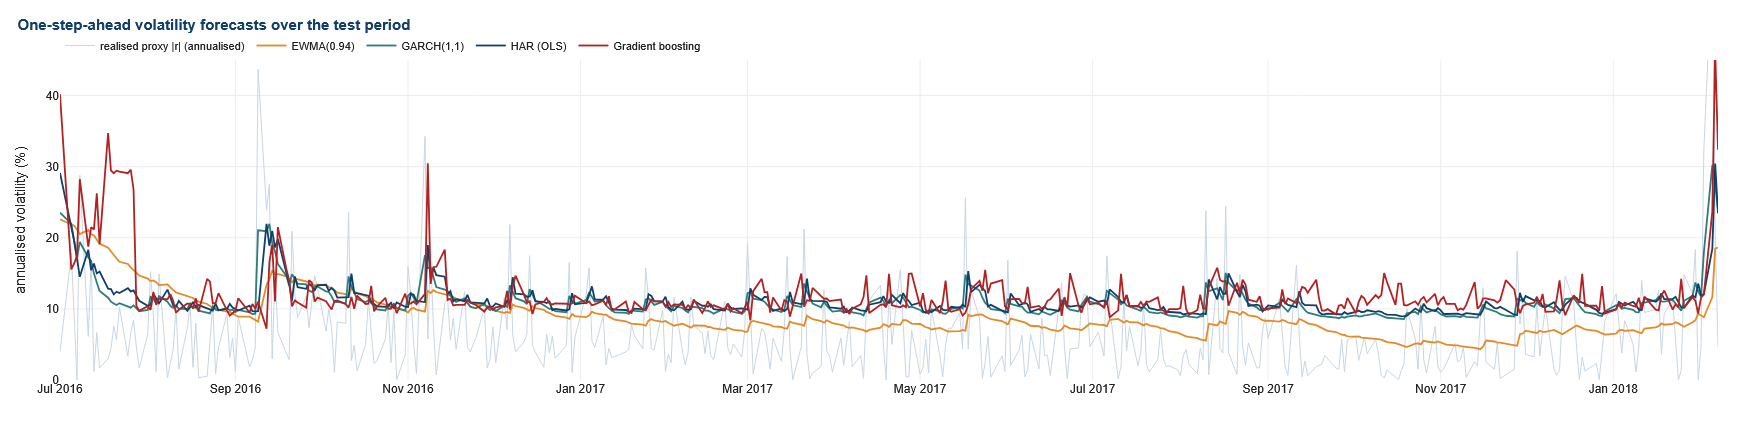

In [7]:
window = slice("2016-07-01", "2018-02-07")
show = ["EWMA(0.94)", "GARCH(1,1)", "HAR (OLS)", "Gradient boosting"]

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=rv.loc[window].index, y=np.sqrt(rv.loc[window] * 252) * 100,
    name="realised proxy |r| (annualised)", mode="lines",
    line=dict(color="#C9D6E4", width=1)))

for name, colour in zip(show, [a6.ORANGE, a6.TEAL, a6.NAVY, a6.RED]):
    s = forecasts[name].loc[window]
    fig.add_trace(go.Scatter(x=s.index, y=np.sqrt(s * 252) * 100, name=name,
                             line=dict(color=colour, width=1.8)))

a6.style(fig, title="One-step-ahead volatility forecasts over the test period",
         xtitle=None, ytitle="annualised volatility (%)", height=430)
fig.update_yaxes(range=[0, 45])
fig.show()

The grey series is the proxy the models are trying to predict, and it is *enormously*
noisy — that spikiness is exactly why you cannot judge these models by eye, and why the
choice of loss function in the next section carries so much weight.

Note how the forecasts differ in **reactivity** rather than in level. EWMA moves fastest
because it has no anchor; GARCH pulls back toward its long-run variance; the tree-based
models step between discrete levels, which is a real limitation when volatility is a
continuous process.

---
## 4. Scoring the forecasts — and why the loss function decides

You never observe volatility. You observe a noisy proxy for it. That changes which loss
functions are safe to use.

[Patton (2011)](https://doi.org/10.1016/j.jeconom.2010.03.034) proved that under a noisy but
unbiased proxy only **MSE on the variance scale** and **QLIKE** are *robust* — they rank
models the way the unobservable truth would. Other losses can **reverse the true ordering**,
and you would never find out.

We deliberately include a non-robust loss (RMSE on the volatility scale) to see what happens.

First, a two-line demonstration of the asymmetry that makes QLIKE the right choice for a
risk manager.

<details>
<summary><b>QLIKE (click to expand)</b></summary>

$$\mathrm{QLIKE}\big(\tilde\sigma^2, \hat h\big)
= \frac{\tilde\sigma^2}{\hat h} - \log\frac{\tilde\sigma^2}{\hat h} - 1 \;\ge\; 0$$

Zero only when $\hat h = \tilde\sigma^2$. It penalises **under**-prediction of variance far
more heavily than over-prediction — the right asymmetry for a risk manager, who would much
rather hold too much capital than too little.

</details>

In [8]:
truth = 1.0                      # true variance, in arbitrary units
too_low = np.array([0.5])        # forecast 50% too LOW  -- under-stating risk
too_high = np.array([1.5])       # forecast 50% too HIGH -- over-stating risk

print(f"{'':22s}{'QLIKE':>10s}{'MSE':>10s}")
print(f"{'forecast 50% too low':22s}{a6.qlike([truth], too_low):>10.4f}"
      f"{a6.mse_loss([truth], too_low):>10.4f}")
print(f"{'forecast 50% too high':22s}{a6.qlike([truth], too_high):>10.4f}"
      f"{a6.mse_loss([truth], too_high):>10.4f}")
print()
print(f"QLIKE penalty ratio (low vs high): "
      f"{a6.qlike([truth], too_low) / a6.qlike([truth], too_high):.2f}x")
print("MSE treats the two errors as equally bad. QLIKE does not -- and a risk")
print("manager would much rather hold too much capital than too little.")

                           QLIKE       MSE
forecast 50% too low      0.3069    0.2500
forecast 50% too high     0.0721    0.2500

QLIKE penalty ratio (low vs high): 4.25x
MSE treats the two errors as equally bad. QLIKE does not -- and a risk
manager would much rather hold too much capital than too little.


In [9]:
test_idx = r.index[r.index > SPLIT]
oos = {name: s.reindex(test_idx) for name, s in forecasts.items()}

scores = a6.loss_table(rv.reindex(test_idx), oos)
scores = scores.sort_values("QLIKE")

display(scores[["QLIKE", "MSE", "RMSE (vol)", "rank QLIKE", "rank MSE", "rank RMSE (vol)"]]
        .style.format({"QLIKE": "{:.4f}", "MSE": "{:.3e}", "RMSE (vol)": "{:.5f}"})
        .set_caption("Out-of-sample forecast losses (lower is better)"))

,QLIKE,MSE,RMSE (vol),rank QLIKE,rank MSE,rank RMSE (vol)
"GARCH(1,1)",1.5362,6.018e-09,0.00433,1,1,1
EWMA(0.94),1.7142,9.212e-09,0.00452,2,4,2
HAR (OLS),1.7328,9.032e-09,0.00500,3,2,3
Random forest,1.7751,9.092e-09,0.00526,4,3,4
Gradient boosting,1.8217,1.358e-08,0.00581,5,6,6
Rolling(250),1.9242,1.054e-08,0.00555,6,5,5
Neural net (MLP),3.0753,1.118e-06,0.02249,7,7,7


In [10]:
best_q = scores.index[scores["rank QLIKE"] == 1][0]
best_r = scores.index[scores["rank RMSE (vol)"] == 1][0]

print(f"Best model under QLIKE       : {best_q}")
print(f"Best model under RMSE (vol)  : {best_r}")
print()

swaps = scores[scores["rank QLIKE"] != scores["rank RMSE (vol)"]]
print(f"{len(swaps)} of {len(scores)} models change rank between the two losses:")
for name, row in swaps.iterrows():
    print(f"   {name:<20s} QLIKE rank {int(row['rank QLIKE'])}  ->  "
          f"RMSE rank {int(row['rank RMSE (vol)'])}")

Best model under QLIKE       : GARCH(1,1)
Best model under RMSE (vol)  : GARCH(1,1)

2 of 7 models change rank between the two losses:
   Gradient boosting    QLIKE rank 5  ->  RMSE rank 6
   Rolling(250)         QLIKE rank 6  ->  RMSE rank 5


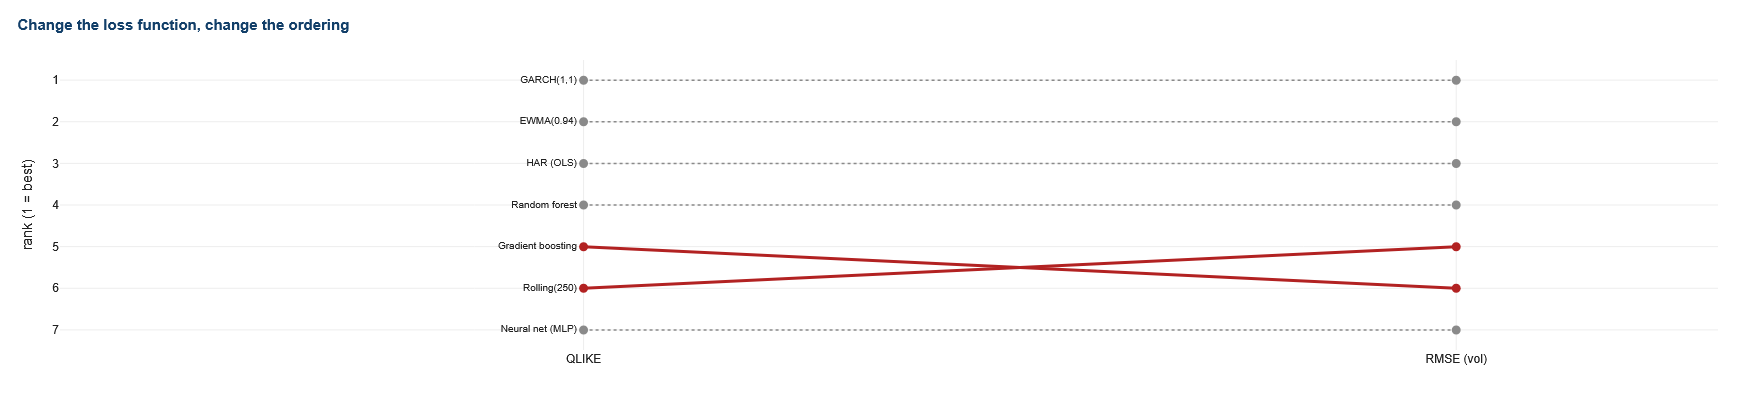

In [11]:
order_q = scores.sort_values("rank QLIKE").index.tolist()

fig = go.Figure()
for name in order_q:
    rq = int(scores.loc[name, "rank QLIKE"])
    rr = int(scores.loc[name, "rank RMSE (vol)"])
    moved = rq != rr
    fig.add_trace(go.Scatter(
        x=["QLIKE", "RMSE (vol)"], y=[rq, rr], name=name, mode="lines+markers+text",
        text=[name, ""], textposition="middle left", textfont=dict(size=10),
        line=dict(width=3 if moved else 1.5,
                  color=a6.RED if moved else a6.GREY,
                  dash="solid" if moved else "dot"),
        marker=dict(size=9)))

a6.style(fig, title="Change the loss function, change the ordering",
         ytitle="rank (1 = best)", height=400, legend_top=False)
fig.update_yaxes(autorange="reversed", dtick=1)
fig.update_xaxes(range=[-0.6, 1.3])
fig.update_layout(showlegend=False)
fig.show()

**Report what you see, not what you hoped to see.** On this sample the *top* of the table is
stable — the same model wins under both losses — while the middle reshuffles. Patton's
theorem says a non-robust loss *can* reverse any pair; it does not promise that it will
reverse the pair you care about in every sample.

That is still a problem, for a reason worth being precise about. You do not know in advance
*which* pairs a non-robust loss will scramble. Here it happened to be ranks 5 and 6; on
another sample it could be ranks 1 and 2, and nothing in the output would warn you. Using a
robust loss is cheap insurance against a failure you cannot detect.

Note also that QLIKE and MSE — **both** robust — disagree about the middle of the table.
That disagreement is finite-sample noise rather than a robustness failure, and it is a good
argument for reporting a Model Confidence Set instead of a single winner.

This is Lecture 5's discipline in a new costume: **the metric is part of the model**, and
choosing it after seeing the results is a form of overfitting.

### So does machine learning help?

Read the QLIKE column, not the story you were expecting.

In [12]:
baseline = scores.loc["EWMA(0.94)", "QLIKE"]
comparison = (scores[["QLIKE"]]
              .assign(**{"vs EWMA (%)": lambda d: 100 * (d["QLIKE"] / baseline - 1)})
              .sort_values("QLIKE"))
display(comparison.style.format({"QLIKE": "{:.4f}", "vs EWMA (%)": "{:+.1f}%"})
        .set_caption("QLIKE relative to a zero-parameter EWMA benchmark"))

,QLIKE,vs EWMA (%)
"GARCH(1,1)",1.5362,-10.4%
EWMA(0.94),1.7142,+0.0%
HAR (OLS),1.7328,+1.1%
Random forest,1.7751,+3.5%
Gradient boosting,1.8217,+6.3%
Rolling(250),1.9242,+12.2%
Neural net (MLP),3.0753,+79.4%


**State the headline finding before interpreting it.** On this information set, GARCH(1,1)
beats the EWMA benchmark by about 10% on QLIKE, and **none of the three machine learning
models beats EWMA at all** — a zero-parameter recursion from 1996 outperforms a tuned random
forest, a gradient booster and a neural network.

That is a real result and you should not explain it away. It is also entirely consistent
with the literature once you read the literature carefully: the published wins come from
models with **more information** (intraday data, or pooling across hundreds of stocks), not
from more flexible functional forms applied to the same three predictors. We have given
every model identical inputs, and flexibility alone earned nothing.

**Now look at where the neural network lands, and at how often it hit the variance floor.** A
small MLP fitted directly on variance has no constraint keeping its output positive, so it
drifts toward zero in quiet periods — and QLIKE, by design, treats a near-zero variance
forecast as an enormous error. The asymmetry we demonstrated above is doing exactly what it
should: it is refusing to let a model understate risk cheaply.

This is not evidence that neural networks cannot forecast volatility. It is evidence that
**fitting them on the wrong scale** does not work. Exercise S1 asks you to refit on log
variance, which enforces positivity automatically, and the result is markedly different.

Whatever your table shows, state it plainly rather than dressing it up. The published
evidence is genuinely mixed, and **the disagreement is itself the lesson**:

- [Christensen, Siggaard and Veliyev (2023)](https://doi.org/10.1093/jjfinec/nbac020) beat
  the HAR lineage using only HAR's own predictors and minimal tuning.
- [Zhang, Zhang, Cucuringu and Qian (2024)](https://doi.org/10.1093/jjfinec/nbad005) find
  neural networks dominate — but their strongest result comes from **pooling across many
  stocks**, an information advantage rather than a functional-form advantage.
- Several recent studies find regime-switching HAR variants still win when the predictor
  set is small, which is precisely our setting here.

The honest summary: on the variance side, machine learning delivers **modest, real,
replicable** improvements — mostly when it has more information than the benchmark, not
merely more flexibility. That is a far better record than anything on the return side, and
far less exciting than the marketing.

> **Scope note.** Everything here is a *single-horizon, historically estimated* conditional
> variance. Multi-asset scenario paths, synthetic scenario generation and reverse stress
> testing belong to **Lecture 10**.

---
## Exercises

### Core

**C1.** Refit the whole horse race with the split moved to `2015-06-30`, giving a shorter
training sample and a longer test sample. Does the QLIKE ranking change? What does that tell
you about how much confidence to place in the original ranking?

**C2.** Add a GJR-GARCH model (`arch_model(..., o=1)`) to the ladder. Does allowing negative
returns to raise volatility more than positive ones improve out-of-sample QLIKE? Report the
fitted asymmetry parameter and say whether its sign matches the leverage effect.

**C3.** The EWMA decay $\lambda = 0.94$ is imposed by convention, not estimated. Sweep
$\lambda$ from 0.85 to 0.99 and plot out-of-sample QLIKE against $\lambda$. Where is the
minimum, and is 0.94 a defensible default for this portfolio?

### Stretch

**S1.** Refit the three machine learning models on **log variance** — that is, regress
`np.log(y)` on `np.log(X)` and exponentiate the prediction — so positivity is enforced by
construction and the variance floor never binds. Rescore under QLIKE. How much of the neural
network's poor showing was the model, and how much was the scale you fitted it on?

**S1b.** Combine the forecasts. Fit a simple average and an inverse-QLIKE-weighted average
of the models, and score the combinations. Forecast combination usually beats its best
component — does it here, and can you explain why or why not?

**S2.** Our proxy is the squared daily return, which is unbiased but extremely noisy. Pick
five tickers, build an equally weighted **cross-sectional** variance proxy for each day, and
rerun the comparison. Does a less noisy proxy change the ranking, and does it change the
gap between the machine learning models and EWMA?

**S3.** Implement the pooling idea from Zhang et al. (2024): train **one** model on the
stacked HAR features of 50 individual tickers, then evaluate it on 10 tickers that were held
out entirely. Does a model that has never seen a stock forecast its volatility better than a
HAR fitted to that stock alone? This is the strongest published claim in the literature, and
it is testable in about thirty lines.